In [1]:
import os
import sys
import subprocess
import time
import json
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

import os, sys, subprocess
import torch

def get_compatible_device():
    if torch.cuda.is_available():
        cap = torch.cuda.get_device_capability(0)
        gpu_name = torch.cuda.get_device_name(0)
        print(f"GPU detected: {gpu_name} | Compute Capability: sm_{cap[0]}{cap[1]}")
        # PyTorch >= 2.3 cu12x wheels drop sm_60 (P100) kernel images
        if cap[0] < 7:
            print(f"WARNING: sm_{cap[0]}{cap[1]} is not supported by this PyTorch build.")
            print("Falling back to CPU for compatibility.")
            return torch.device("cpu")
        return torch.device("cuda")
    else:
        print("No CUDA GPU available. Running on CPU.")
        return torch.device("cpu")

device = get_compatible_device()
print(f"\nPyTorch Version : {torch.__version__}")
print(f"Active Device   : {device}")
if device.type == "cuda":
    total_vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"Total VRAM      : {total_vram:.2f} GB")


GPU detected: NVIDIA GeForce RTX 5060 Laptop GPU | Compute Capability: sm_120

PyTorch Version : 2.11.0+cu128
Active Device   : cuda
Total VRAM      : 7.96 GB


# Deep Learning Architecture Benchmark: Transfer Learning vs Scratch on 10 Monkey Species

This notebook presents a comprehensive comparison of **5 distinct Computer Vision architectures** evaluated on the **10 Monkey Species Dataset**:
1. **TinyVGG** (Custom baseline trained from scratch)
2. **ResNet-18** (Pretrained, Feature Extractor)
3. **EfficientNet-B0** (Pretrained, Feature Extractor)
4. **EfficientNet-B7** (Pretrained, Feature Extractor, High Resolution 600x600)
5. **MobileNetV3-Small** (Pretrained, Edge-Optimized Feature Extractor)

---
### Workflow Steps:
1. **Environment Setup & GPU Verification** (CUDA & VRAM detection)
2. **Data Preparation & Label Parsing** (Mapping 'n0'-'n9' to human-readable species names)
3. **Model Factory & Feature Extractor Freezing**
4. **Training Engine with Automatic Mixed Precision (AMP)**
5. **Sequential Benchmark Execution (10 Epochs per Architecture)**
6. **Performance Curves (Loss & Accuracy)**
7. **Confusion Matrices (10-Class Heatmaps)**
8. **Comparative Analysis & Summary Visualizations**


## 1. Environment Setup and GPU Hardware Inspection

In [2]:
import os
from pathlib import Path

def get_data_paths():
    # Kaggle: slothkong/10-monkey-species mounts at /kaggle/input/10-monkey-species/
    # OR /kaggle/input/datasets/slothkong/10-monkey-species/
    kaggle_roots = [
        Path('/kaggle/input/10-monkey-species'),
        Path('/kaggle/input/datasets/slothkong/10-monkey-species'),
    ]
    for kaggle_root in kaggle_roots:
        if not kaggle_root.exists():
            continue
        # Try direct known paths first
        for tr_path in [
            kaggle_root / 'training' / 'training',
            kaggle_root / 'training',
        ]:
            if not tr_path.exists():
                continue
            for val_path in [
                kaggle_root / 'validation' / 'validation',
                kaggle_root / 'validation',
            ]:
                if val_path.exists() and (val_path / 'n0').exists():
                    lbl = None
                    for lbl_c in [kaggle_root / 'monkey_labels.txt']:
                        if lbl_c.exists():
                            lbl = str(lbl_c)
                    return str(tr_path), str(val_path), lbl
        # Fallback: scan all subdirs, pick ones named 'training*'
        for d in sorted(kaggle_root.rglob('*')):
            if d.is_dir() and 'train' in d.name.lower() and (d / 'n0').exists():
                tr = d
                # look for sibling validation
                for val_candidate in [
                    tr.parent.parent / 'validation' / 'validation',
                    tr.parent.parent / 'validation',
                    tr.parent / 'validation' / 'validation',
                    tr.parent / 'validation',
                ]:
                    if val_candidate.exists() and (val_candidate / 'n0').exists():
                        gp = tr.parent.parent
                        lbl = None
                        for lbl_c in [gp / 'monkey_labels.txt', kaggle_root / 'monkey_labels.txt']:
                            if lbl_c.exists():
                                lbl = str(lbl_c)
                                break
                        return str(tr), str(val_candidate), lbl

    # Local fallback
    for tr, val, lbl in [
        ('data/training/training', 'data/validation/validation', 'data/monkey_labels.txt'),
        ('data/training', 'data/validation', 'data/monkey_labels.txt'),
        ('../data/training/training', '../data/validation/validation', '../data/monkey_labels.txt'),
    ]:
        if os.path.exists(tr) and os.path.exists(val):
            return tr, val, lbl if os.path.exists(lbl) else None

    raise FileNotFoundError(
        'Dataset not found. On Kaggle add dataset: slothkong/10-monkey-species. '
        'Locally: kaggle datasets download -d slothkong/10-monkey-species -p data --unzip'
    )

train_dir, val_dir, labels_file = get_data_paths()
print(f"Training path   : {train_dir}")
print(f"Validation path : {val_dir}")
print(f"Labels file     : {labels_file}")

# Sanity check
assert train_dir != val_dir, "ERROR: Training and validation paths are the same!"
assert os.path.exists(os.path.join(train_dir, 'n0')), f"Class 'n0' not found in training dir: {train_dir}"
assert os.path.exists(os.path.join(val_dir, 'n0')), f"Class 'n0' not found in validation dir: {val_dir}"
print("Path sanity check passed.")

def parse_labels(labels_path):
    mapping = {}
    if labels_path and os.path.exists(labels_path):
        with open(labels_path, encoding='utf-8') as f:
            for line in f:
                parts = [p.strip() for p in line.strip().split(',')]
                if len(parts) >= 3 and not line.startswith('Label'):
                    mapping[parts[0]] = parts[2].replace(' ', '_')
    return mapping

label_mapping = parse_labels(labels_file)
print(f"\nFound {len(label_mapping)} species labels:")
for k, v in label_mapping.items():
    print(f"  {k} -> {v}")


Training path   : ../data/training/training
Validation path : ../data/validation/validation
Labels file     : ../data/monkey_labels.txt
Path sanity check passed.

Found 10 species labels:
  n0 -> mantled_howler
  n1 -> patas_monkey
  n2 -> bald_uakari
  n3 -> japanese_macaque
  n4 -> pygmy_marmoset
  n5 -> white_headed_capuchin
  n6 -> silvery_marmoset
  n7 -> common_squirrel_monkey
  n8 -> black_headed_night_monkey
  n9 -> nilgiri_langur


## 2. Dataset Discovery and Species Label Parsing

## 3. Model Architecture Factory

In [3]:
class TinyVGG(nn.Module):
    def __init__(self, in_channels: int = 3, hidden_units: int = 16, out_shape: int = 10) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels, hidden_units, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 16 * 16, out_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

def get_model_and_transform(name: str, num_classes: int = 10):
    name = name.lower()
    if name == "tinyvgg":
        model = TinyVGG(in_channels=3, hidden_units=16, out_shape=num_classes)
        transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        return model, transform
    elif name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model, weights.transforms()
    elif name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        in_f = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_f, num_classes))
        return model, weights.transforms()
    elif name == "efficientnet_b7":
        weights = models.EfficientNet_B7_Weights.DEFAULT
        model = models.efficientnet_b7(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        in_f = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_f, num_classes))
        return model, weights.transforms()
    elif name == "mobilenet_v3_small":
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        model = models.mobilenet_v3_small(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        in_f = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_f, num_classes)
        return model, weights.transforms()
    else:
        raise ValueError(f"Unknown architecture: {name}")


## 4. Training Engine with Automatic Mixed Precision (AMP)

In [4]:
def train_step(model, dataloader, loss_fn, optimizer, device, scaler):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    total = 0
    for X, y in dataloader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        bs = X.size(0)
        total += bs
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * bs
        train_acc += (y_pred.argmax(1) == y).sum().item()
    return train_loss / total, train_acc / total

def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0.0, 0.0
    total = 0
    preds, targets = [], []
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            bs = X.size(0)
            total += bs
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            test_loss += loss.item() * bs
            pred_labels = y_pred.argmax(1)
            test_acc += (pred_labels == y).sum().item()
            preds.extend(pred_labels.cpu().tolist())
            targets.extend(y.cpu().tolist())
    return test_loss / total, test_acc / total, preds, targets

def train_and_eval(model_name, epochs=10, batch_size=32, lr=0.001):
    torch.manual_seed(42)
    model, transform = get_model_and_transform(model_name, num_classes=10)
    model = model.to(device)

    train_data = datasets.ImageFolder(train_dir, transform=transform)
    val_data = datasets.ImageFolder(val_dir, transform=transform)
    classes = [label_mapping.get(c, c) for c in train_data.classes]

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=(device.type=="cuda"))
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device.type=="cuda"))

    total_p = sum(p.numel() for p in model.parameters())
    trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_p = total_p - trainable_p

    print(f"\n{'='*70}\nTraining {model_name.upper()} | Total Params: {total_p:,} | Trainable: {trainable_p:,}\n{'='*70}")

    loss_fn = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)
    scaler = torch.amp.GradScaler(device.type, enabled=(device.type=="cuda"))

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    start_time = time.time()
    final_preds, final_targets = [], []

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_step(model, train_loader, loss_fn, optimizer, device, scaler)
        te_loss, te_acc, preds, targets = test_step(model, val_loader, loss_fn, device)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)
        final_preds, final_targets = preds, targets
        print(f"Epoch [{ep:02d}/{epochs:02d}] | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.2f}% | Test Loss: {te_loss:.4f} | Test Acc: {te_acc*100:.2f}%")

    elapsed = time.time() - start_time
    return {
        "name": model_name,
        "model": model,
        "history": history,
        "preds": final_preds,
        "targets": final_targets,
        "classes": classes,
        "total_params": total_p,
        "trainable_params": trainable_p,
        "frozen_params": frozen_p,
        "elapsed": elapsed,
        "final_acc": history["test_acc"][-1] * 100,
        "final_loss": history["test_loss"][-1]
    }


## 5. Sequential Training of All 5 Architectures

In [5]:
all_benchmark_results = {}
configs = [
    ("tinyvgg", 32),
    ("resnet18", 32),
    ("efficientnet_b0", 32),
    ("efficientnet_b7", 8),       # Batch size 8 to fit 600x600 resolution into GPU memory
    ("mobilenet_v3_small", 32)
]

for name, bs in configs:
    res = train_and_eval(model_name=name, epochs=10, batch_size=bs, lr=0.001)
    all_benchmark_results[name] = res



Training TINYVGG | Total Params: 48,378 | Trainable: 48,378


Epoch [01/10] | Train Loss: 2.1314 | Train Acc: 22.52% | Test Loss: 1.9261 | Test Acc: 28.31%


Epoch [02/10] | Train Loss: 1.7301 | Train Acc: 38.38% | Test Loss: 1.6961 | Test Acc: 41.18%


Epoch [03/10] | Train Loss: 1.4904 | Train Acc: 49.23% | Test Loss: 1.5436 | Test Acc: 46.69%


Epoch [04/10] | Train Loss: 1.2482 | Train Acc: 58.43% | Test Loss: 1.5062 | Test Acc: 44.85%


...

Epoch [06/10] | Train Loss: 0.1966 | Train Acc: 97.72% | Test Loss: 0.1662 | Test Acc: 97.06%


Epoch [07/10] | Train Loss: 0.1708 | Train Acc: 98.09% | Test Loss: 0.1585 | Test Acc: 96.69%


Epoch [08/10] | Train Loss: 0.1495 | Train Acc: 97.63% | Test Loss: 0.1550 | Test Acc: 96.69%


Epoch [09/10] | Train Loss: 0.1230 | Train Acc: 99.09% | Test Loss: 0.1539 | Test Acc: 96.69%


Epoch [10/10] | Train Loss: 0.1149 | Train Acc: 98.72% | Test Loss: 0.1503 | Test Acc: 96.69%


## 6. Model Performance Summary Table

In [6]:
summary_rows = []
for name, res in all_benchmark_results.items():
    summary_rows.append({
        "Architecture": name.upper(),
        "Paradigm": "Scratch" if name == "tinyvgg" else "Pretrained (Feature Extractor)",
        "Test Accuracy (%)": f"{res['final_acc']:.2f}%",
        "Test Loss": f"{res['final_loss']:.4f}",
        "Training Time (s)": f"{res['elapsed']:.2f}s",
        "Total Parameters": f"{res['total_params']:,}",
        "Trainable Parameters": f"{res['trainable_params']:,}"
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)


,Architecture,Paradigm,Test Accuracy (%),Test Loss,Training Time (s),Total Parameters,Trainable Parameters
0,TINYVGG,Scratch,58.09%,1.8172,131.79s,"48,378","48,378"
1,RESNET18,Pretrained (Feature Extractor),97.06%,0.1337,159.08s,"11,181,642","5,130"
2,EFFICIENTNET_B0,Pretrained (Feature Extractor),97.06%,0.1428,179.78s,"4,020,358","12,810"
3,EFFICIENTNET_B7,Pretrained (Feature Extractor),100.00%,0.0408,496.34s,"63,812,570","25,610"
4,MOBILENET_V3_SMALL,Pretrained (Feature Extractor),96.69%,0.1503,167.43s,"1,528,106","10,250"


## 7. Comparative Visualizations

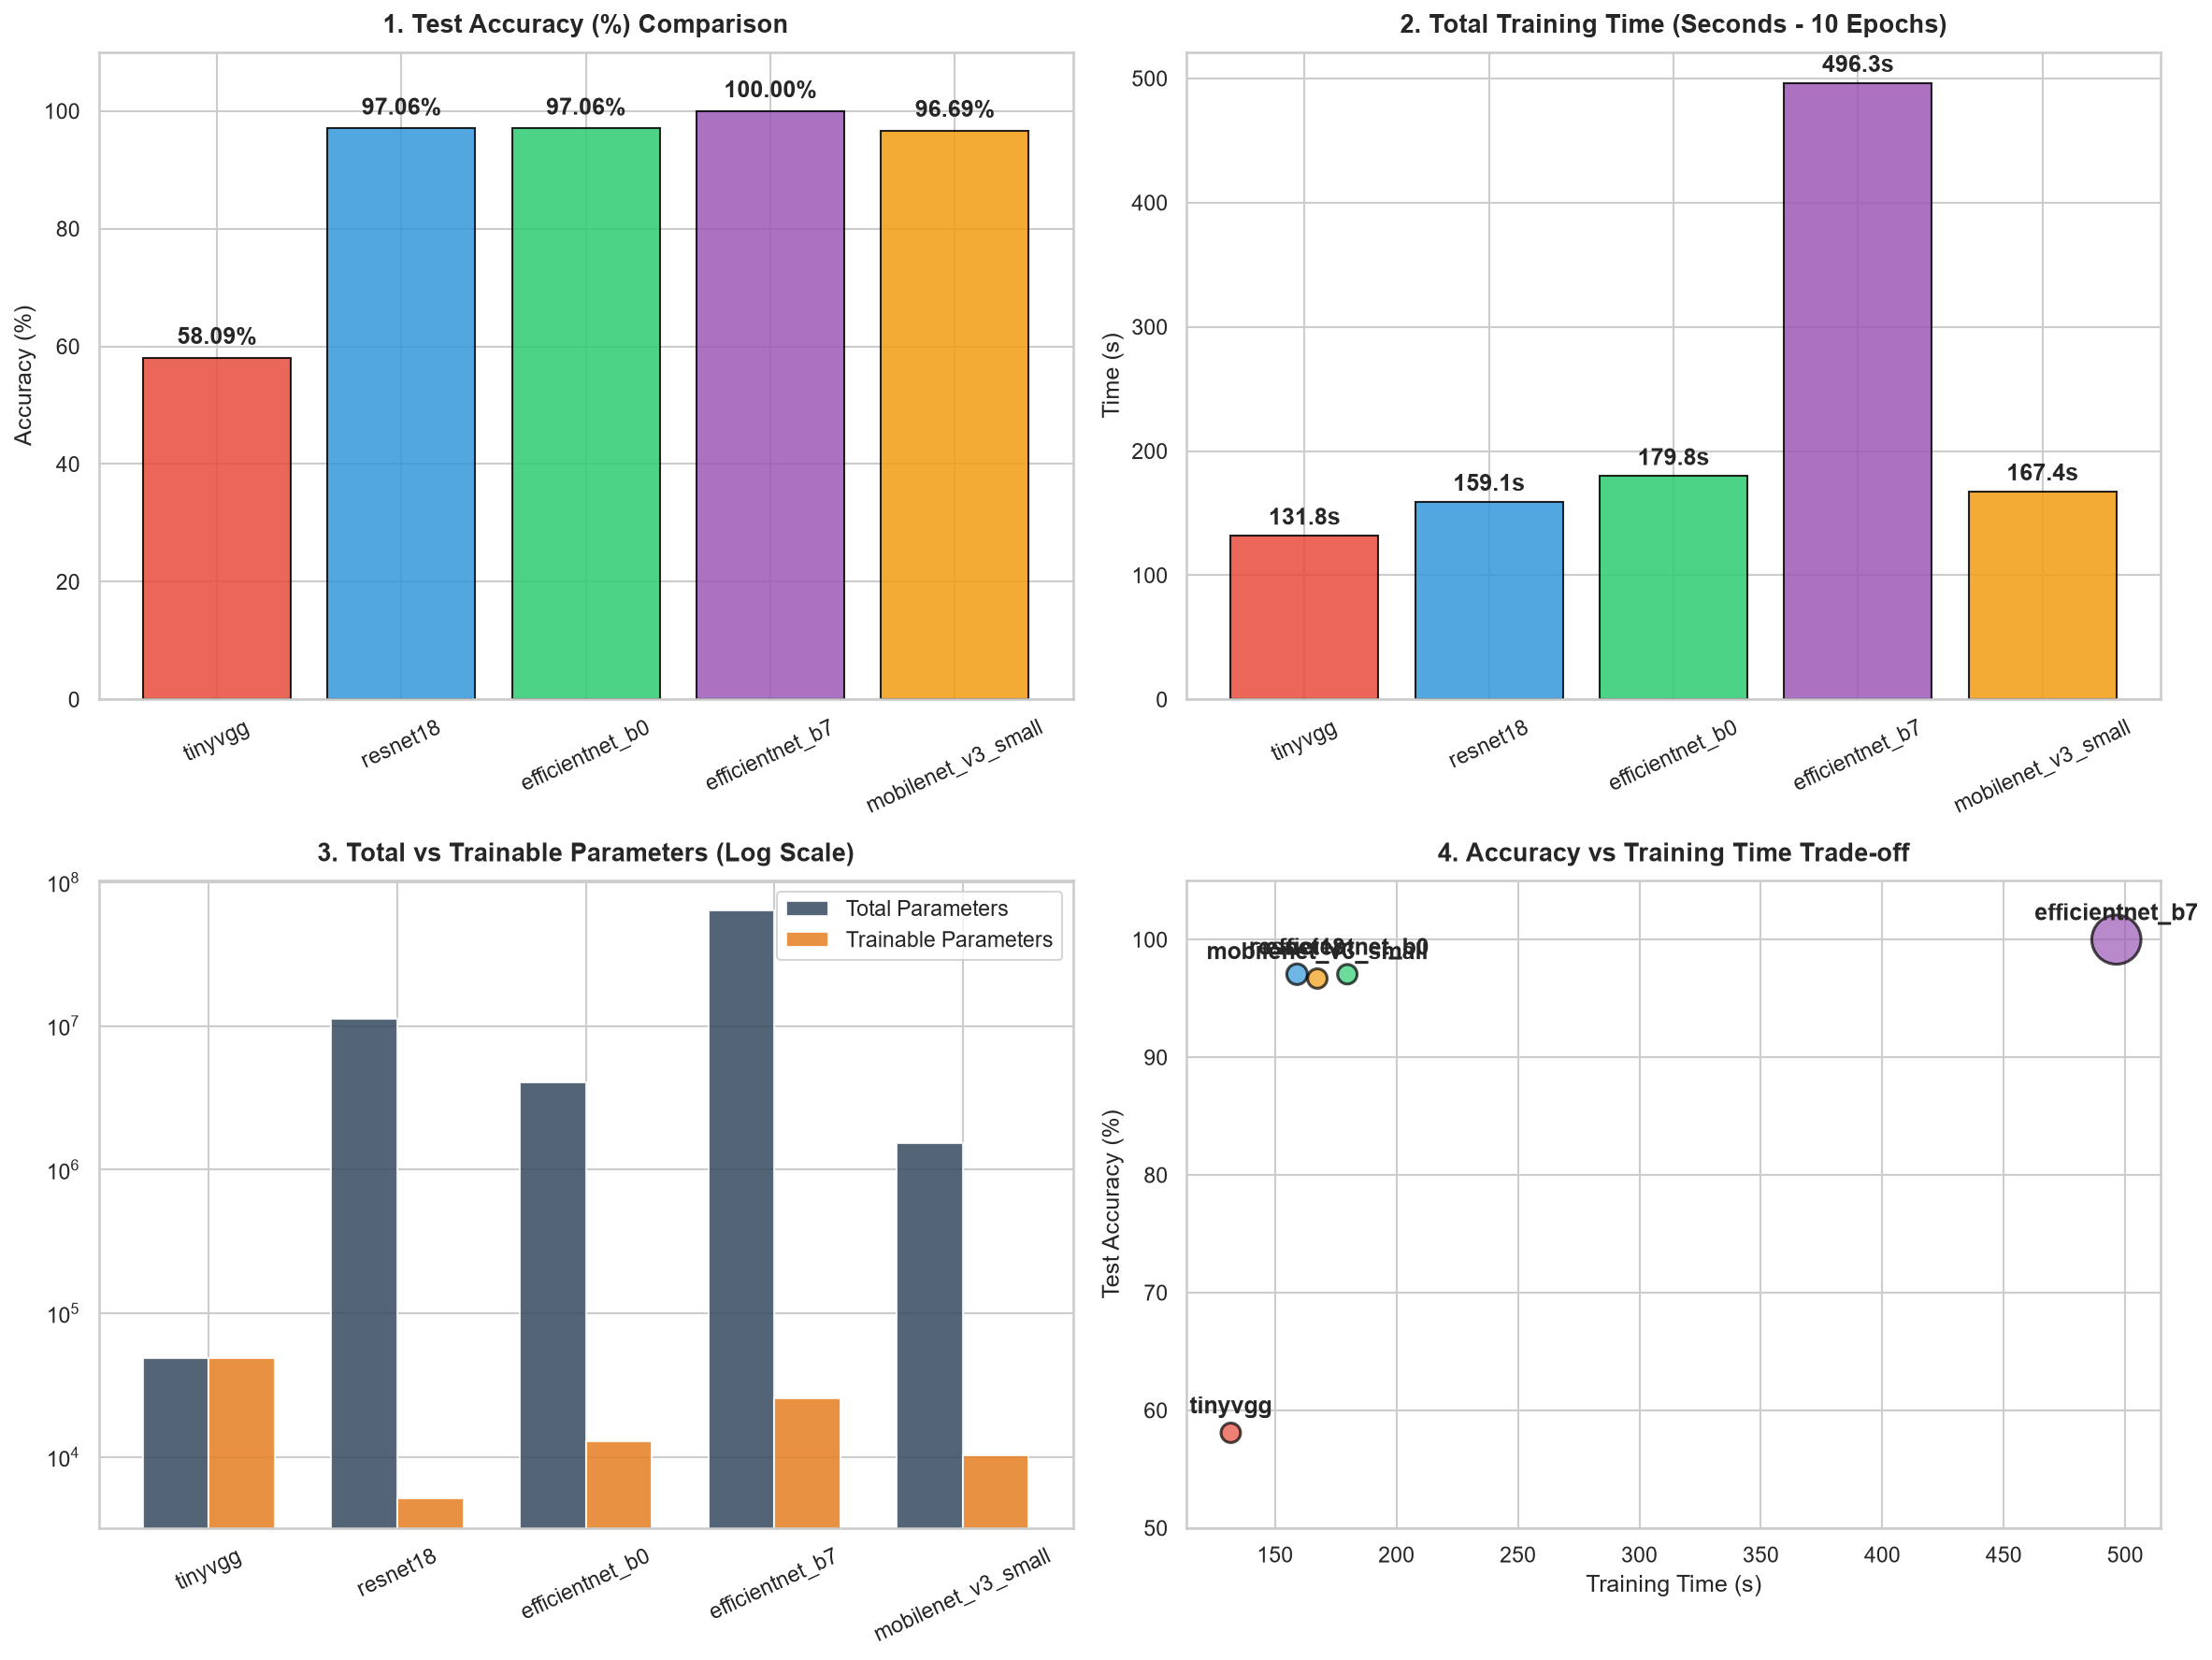

In [7]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
plt.subplots_adjust(hspace=0.35, wspace=0.25)

models_list = list(all_benchmark_results.keys())
accuracies = [all_benchmark_results[m]["final_acc"] for m in models_list]
times = [all_benchmark_results[m]["elapsed"] for m in models_list]
totals = [all_benchmark_results[m]["total_params"] for m in models_list]
trainables = [all_benchmark_results[m]["trainable_params"] for m in models_list]

colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6", "#f39c12"]

# 1. Accuracy
ax1 = axes[0, 0]
bars1 = ax1.bar(models_list, accuracies, color=colors, edgecolor="black", alpha=0.85)
ax1.set_title("1. Test Accuracy (%) Comparison", fontsize=13, fontweight="bold", pad=10)
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim([0, 110])
ax1.tick_params(axis="x", rotation=25)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha="center", va="bottom", fontweight="bold")

# 2. Time
ax2 = axes[0, 1]
bars2 = ax2.bar(models_list, times, color=colors, edgecolor="black", alpha=0.85)
ax2.set_title("2. Total Training Time (Seconds - 10 Epochs)", fontsize=13, fontweight="bold", pad=10)
ax2.set_ylabel("Time (s)")
ax2.tick_params(axis="x", rotation=25)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f"{yval:.1f}s", ha="center", va="bottom", fontweight="bold")

# 3. Parameters
ax3 = axes[1, 0]
x_pos = np.arange(len(models_list))
w = 0.35
ax3.bar(x_pos - w/2, totals, width=w, label="Total Parameters", color="#34495e", alpha=0.85)
ax3.bar(x_pos + w/2, trainables, width=w, label="Trainable Parameters", color="#e67e22", alpha=0.85)
ax3.set_yscale("log")
ax3.set_xticks(x_pos)
ax3.set_xticklabels(models_list, rotation=25)
ax3.set_title("3. Total vs Trainable Parameters (Log Scale)", fontsize=13, fontweight="bold", pad=10)
ax3.legend()

# 4. Accuracy vs Time Trade-off
ax4 = axes[1, 1]
ax4.scatter(times, accuracies, s=[max(100, p/100000) for p in totals], c=colors, alpha=0.7, edgecolors="black", linewidth=1.5)
for i, txt in enumerate(models_list):
    ax4.annotate(txt, (times[i], accuracies[i]), xytext=(0, 10), textcoords="offset points", ha="center", fontweight="bold")
ax4.set_title("4. Accuracy vs Training Time Trade-off", fontsize=13, fontweight="bold", pad=10)
ax4.set_xlabel("Training Time (s)")
ax4.set_ylabel("Test Accuracy (%)")
ax4.set_ylim([50, 105])

plt.tight_layout()
plt.show()


## 8. Confusion Matrices for All 5 Architectures

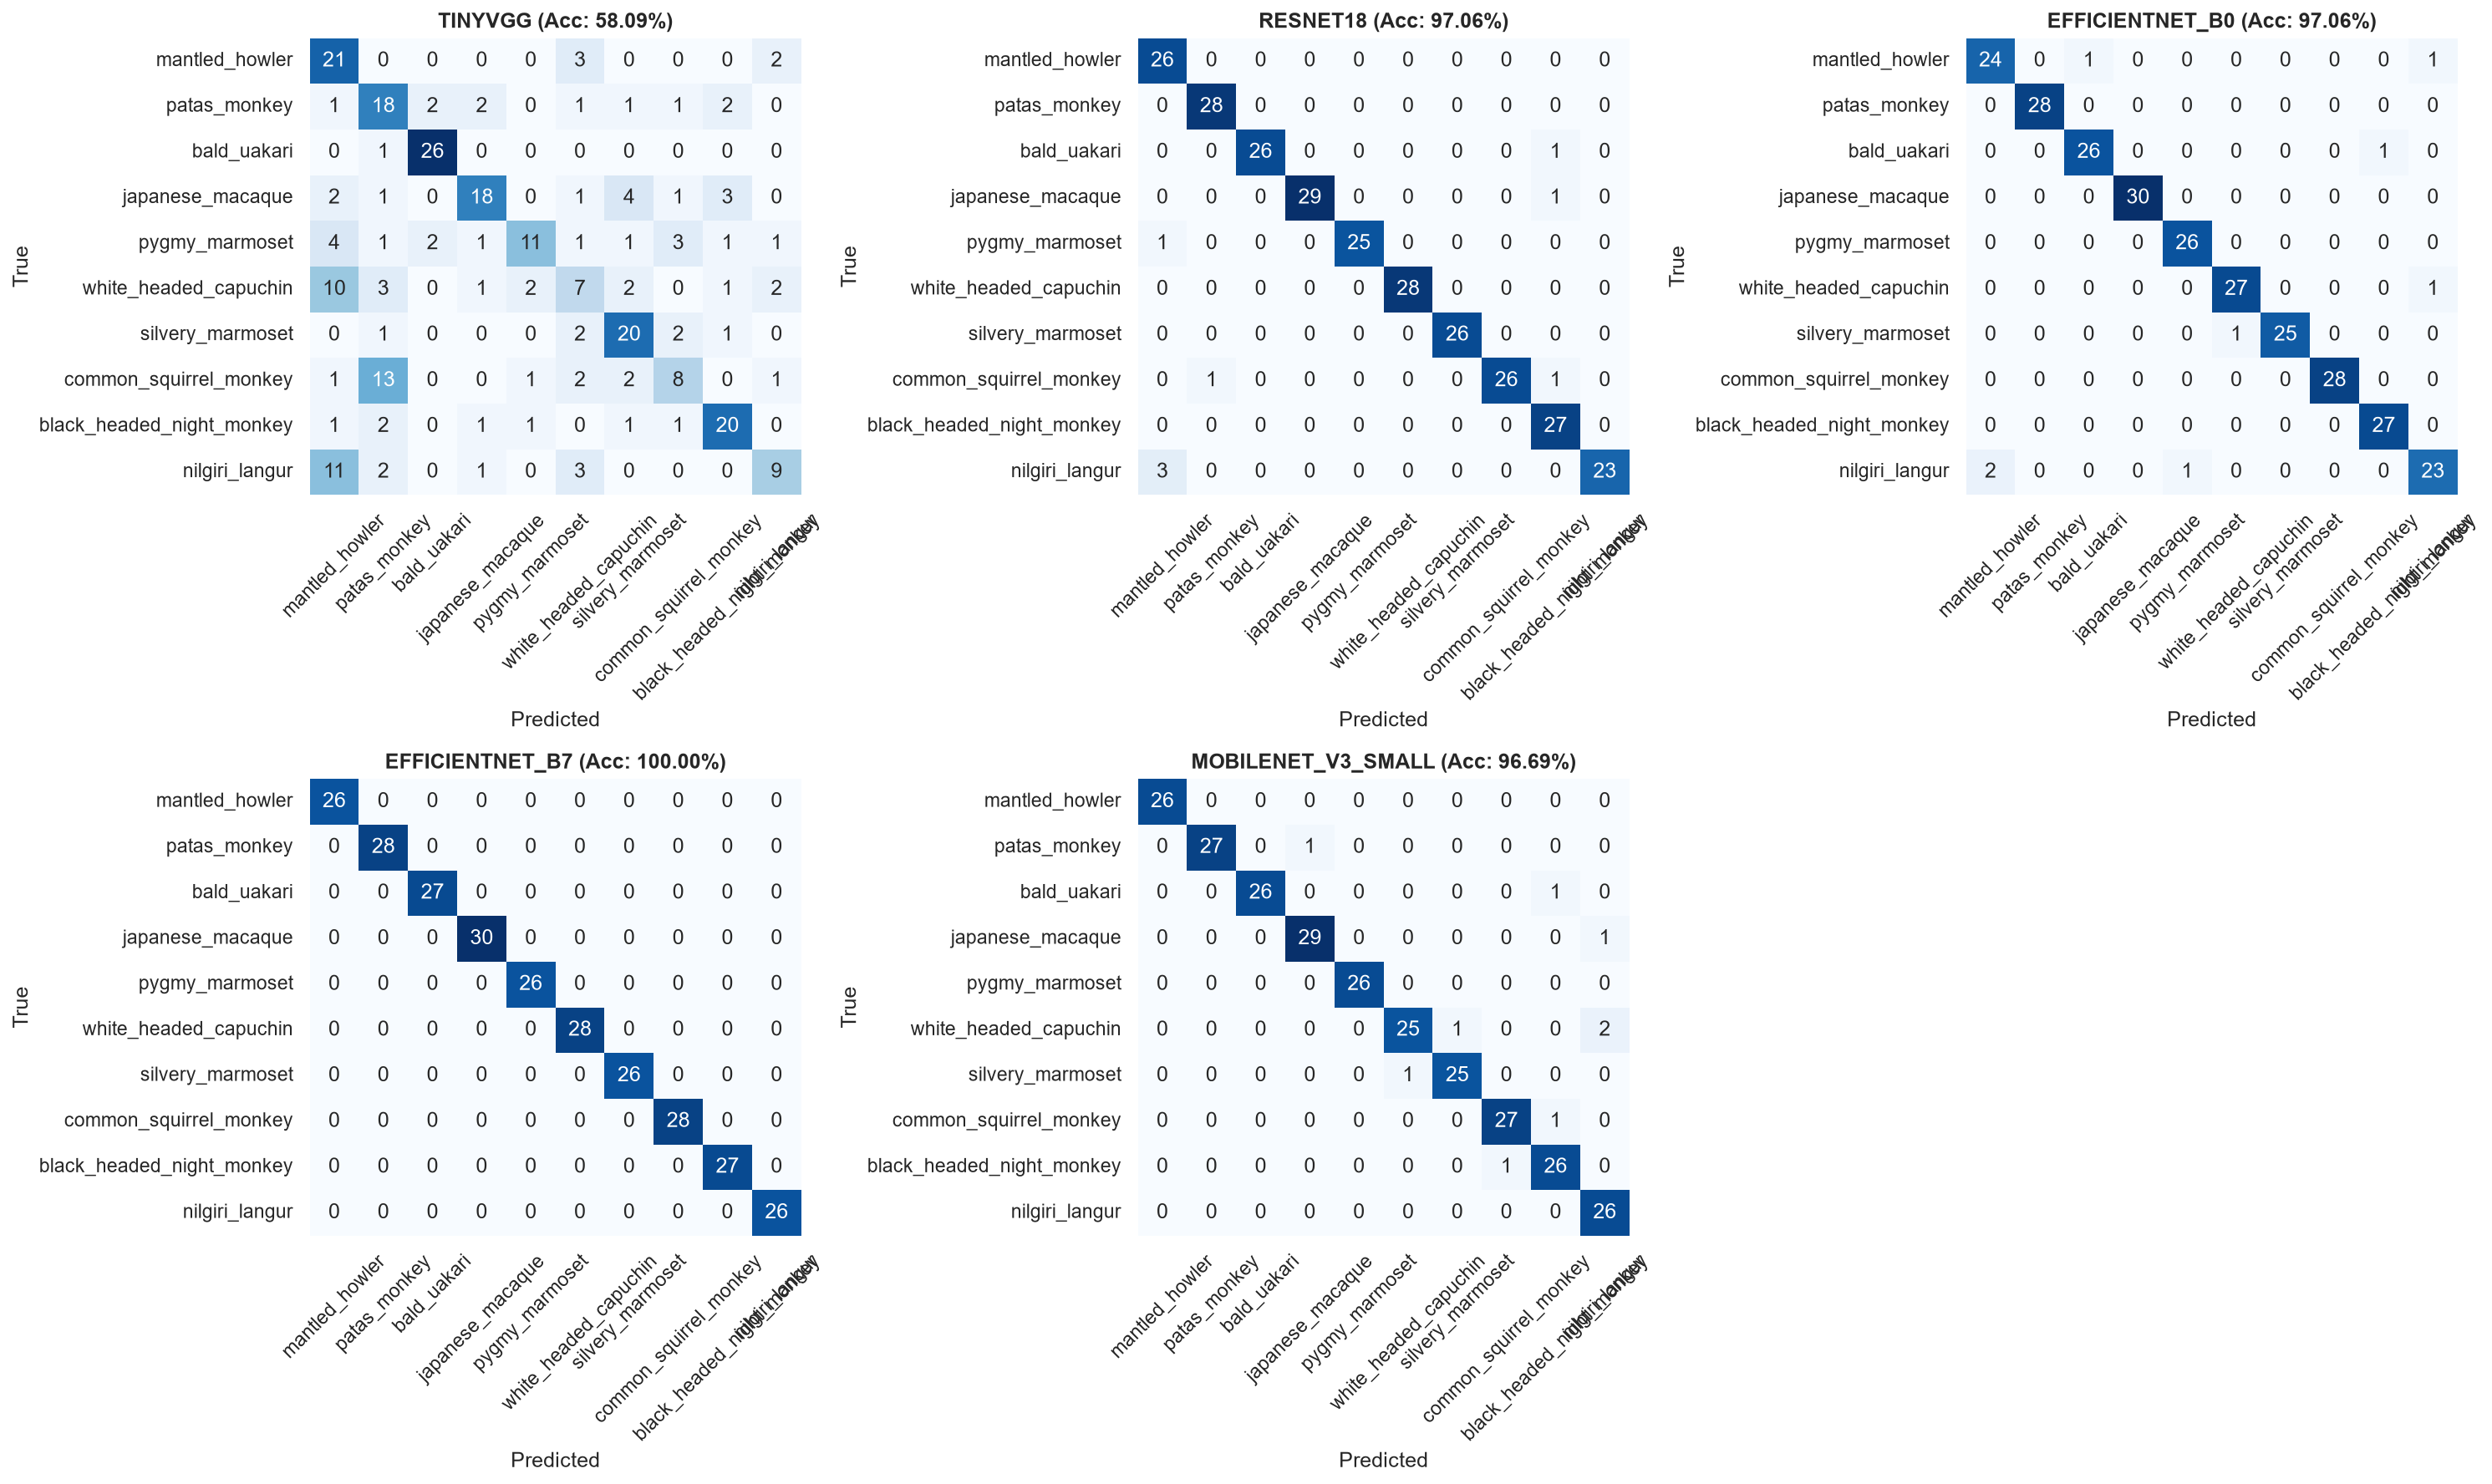

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12), dpi=150)
axes_flat = axes.flatten()

for idx, (name, res) in enumerate(all_benchmark_results.items()):
    ax = axes_flat[idx]
    cm = confusion_matrix(res["targets"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=res["classes"], yticklabels=res["classes"], ax=ax, cbar=False)
    ax.set_title(f"{name.upper()} (Acc: {res['final_acc']:.2f}%)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)

# Remove unused 6th subplot
fig.delaxes(axes_flat[5])
plt.tight_layout()
plt.show()
